# PCG Baseline Model
A PCG-only 1D CNN for HFrEF prediction. The processed data is split at the subject level to prevent data leakage and handle class imbalance using a weighted loss function.

The input has 4 channels (APEX, LLSB, LUSB, RUSB), with 30 seconds for each channel, sampled at 4000 Hz. Run the preprocessing notebook first; it prepares the test set too.

In [ ]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import DataLoader

PROJECT_DIR = '/kaggle/working/ecg-pcg-fusion-hfref'
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)
from src.data_loader import ProcessedCardioDataset, get_dataloaders
from src.pcg_model import PCG_Encoder
from src.preprocessing import CHANNEL_ORDER, PCG_FS, PCG_SAMPLES

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROCESSED_DIR = '/kaggle/input/datasets/nadinemohamed181818/hfref-processed-pcg-ecg/ecg-pcg-fusion-hfref/data/processed/patient_4ch/development'
metadata_path = os.path.join(PROCESSED_DIR, 'processed_metadata.csv')
if not os.path.isfile(metadata_path):
    raise FileNotFoundError('Run 1_preprocessing.ipynb first to save the patient tensors.')
metadata = pd.read_csv(metadata_path, dtype={'Patient_ID': str})

VALIDATION_FOLD = 0
assert metadata['Patient_ID'].is_unique
assert metadata['Fold'].isin(range(5)).all()

train_df = metadata[metadata['Fold'] != VALIDATION_FOLD].reset_index(drop=True)
val_df = metadata[metadata['Fold'] == VALIDATION_FOLD].reset_index(drop=True)

assert set(train_df['Patient_ID']).isdisjoint(val_df['Patient_ID'])
assert set(train_df['Label']) == {0, 1}
assert set(val_df['Label']) == {0, 1}

print(f"Training patients: {len(train_df)}")
print(f"Validation patients: {len(val_df)}")

Training patients: 400
Validation patients: 100


## Initialize Dataloaders and Model
PyTorch `.pt` tensors are directly loaded from disk.

Each PCG tensor is `(4, 120000)` before batching — 8x longer than the ECG tensors, since PCG is sampled at 4000 Hz vs ECG's 500 Hz. The stem in `PCG_Encoder` downsamples more aggressively to compensate, so the final sequence length before pooling matches the ECG model's (469).

In [ ]:
batch_size = 16

train_loader, val_loader = get_dataloaders(
    train_df, val_df, data_dir=PROCESSED_DIR, batch_size=batch_size,
    modality='pcg', seed=SEED,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_config = {'in_channels': 4, 'feature_dim': 64, 'dropout': 0.5}
pcg_model = PCG_Encoder(**model_config).to(device)

sample_pcg, sample_labels = next(iter(val_loader))
assert sample_pcg.shape[1:] == (4, PCG_SAMPLES)

print(f"DataLoaders ready. Training batches: {len(train_loader)}")
print(f"Model initialized on device: {device}")
print(f"Input shape: {sample_pcg.shape}")

DataLoaders ready. Training batches: 25
Model initialized on device: cpu
Input shape: torch.Size([16, 4, 120000])


## Training Loop
Same class imbalance as the ECG baseline (~440 Non-HFrEF to ~60 HFrEF across folds), so we reuse Focal Loss, AdamW, a plateau LR scheduler, and early stopping — all architecture-agnostic, unchanged from the ECG notebook.

### Focal Loss
$$ FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t) $$

- alpha: controls class weighting 
- gamma: focuses on difficult examples

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.88, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        # Compute the probability of the correct class
        pt = torch.where(targets == 1, probs, 1 - probs)
        # minority class (HFrEF) gets a much larger weight (alpha=0.88)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

In [ ]:
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

num_epochs = 50
learning_rate = 1e-3
weight_decay = 1e-3
patience = 10

focal_alpha = float((train_df['Label'] == 0).mean())
criterion = FocalLoss(alpha=focal_alpha, gamma=2.0).to(device)
optimizer = optim.AdamW(pcg_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_auroc = -float('inf')
epochs_without_improvement = 0
history = []
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, f'best_pcg_4ch_fold{VALIDATION_FOLD}.pt')

def augment_batch(pcg_batch):
    # pcg_batch: (batch, 4, 120000) — augmentations preserve the full recording,
    # so no risk of cropping out the only diagnostically relevant segment.
    batch_size = pcg_batch.size(0)

    # 1. Small additive Gaussian noise (simulates recording variability)
    noise = torch.randn_like(pcg_batch) * 0.02
    pcg_batch = pcg_batch + noise

    # 2. Small random amplitude scaling per sample (simulates mic/gain variation)
    scale = (0.9 + 0.2 * torch.rand(batch_size, 1, 1, device=pcg_batch.device))
    pcg_batch = pcg_batch * scale

    return pcg_batch

def same_class_mixup(pcg_batch, labels, alpha=0.2):
    # Only mixes recordings that share the same label, so the mixed
    # example's label is unambiguous — never a blend of HFrEF and non-HFrEF.
    batch_size = pcg_batch.size(0)
    mixed = pcg_batch.clone()

    for label_value in labels.unique():
        idx = (labels == label_value).nonzero(as_tuple=True)[0]
        if len(idx) < 2:
            continue  # need at least 2 same-label examples to mix
        shuffled_idx = idx[torch.randperm(len(idx))]
        lam = torch.distributions.Beta(alpha, alpha).sample((len(idx), 1, 1)).to(pcg_batch.device)
        mixed[idx] = lam * pcg_batch[idx] + (1 - lam) * pcg_batch[shuffled_idx]

    return mixed
    
for epoch in range(num_epochs):
    pcg_model.train()
    train_loss = 0.0

    for pcg, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        labels = labels.to(device).unsqueeze(1)
        pcg = pcg.to(device)
        pcg = same_class_mixup(pcg, labels.squeeze())
        pcg = augment_batch(pcg) 
        
        optimizer.zero_grad(set_to_none=True)
        outputs = pcg_model(pcg)
        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise ValueError("Training loss is not finite.")
        loss.backward()
        nn.utils.clip_grad_norm_(pcg_model.parameters(), max_norm=1.0, error_if_nonfinite=True)
        optimizer.step()
        train_loss += loss.item() * pcg.size(0)

    epoch_train_loss = train_loss / len(train_loader.dataset)

    pcg_model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for pcg, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            pcg = pcg.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = pcg_model(pcg)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * pcg.size(0)

            preds = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())

    epoch_val_loss = val_loss / len(val_loader.dataset)

    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

    history.append({
        'epoch': epoch + 1,
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,
        'val_auroc': auroc,
        'val_auprc': auprc,
        'lr': optimizer.param_groups[0]['lr'],
    })
    scheduler.step(auroc)

    if auroc > best_auroc:
        print(f"Validation AUROC improved from {best_auroc:.4f} to {auroc:.4f}. Saving improved model.")
        best_auroc = auroc
        epochs_without_improvement = 0
        torch.save(pcg_model.state_dict(), MODEL_SAVE_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping. Best validation AUROC: {best_auroc:.4f}")
            break

pcg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
pcg_model.eval()

history = pd.DataFrame(history)
history.to_csv(MODEL_SAVE_PATH.replace('.pt', '.history.csv'), index=False)

Epoch 1/50 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]


Epoch 1 | Train Loss: 0.0881 | Val Loss: 0.0441 | AUROC: 0.5189 | AUPRC: 0.1841
Validation AUROC improved from -inf to 0.5189. Saving improved model.


Epoch 2/50 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.41it/s]


Epoch 2 | Train Loss: 0.0409 | Val Loss: 0.0368 | AUROC: 0.6013 | AUPRC: 0.1718
Validation AUROC improved from 0.5189 to 0.6013. Saving improved model.


Epoch 3/50 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.35it/s]


...

Epoch 13 | Train Loss: 0.0180 | Val Loss: 0.0658 | AUROC: 0.6354 | AUPRC: 0.2909


Epoch 14/50 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.36it/s]


Epoch 14 | Train Loss: 0.0163 | Val Loss: 0.0603 | AUROC: 0.6259 | AUPRC: 0.2774


Epoch 15/50 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.40it/s]

Epoch 15 | Train Loss: 0.0131 | Val Loss: 0.0869 | AUROC: 0.6032 | AUPRC: 0.2612
Early stopping. Best validation AUROC: 0.6856


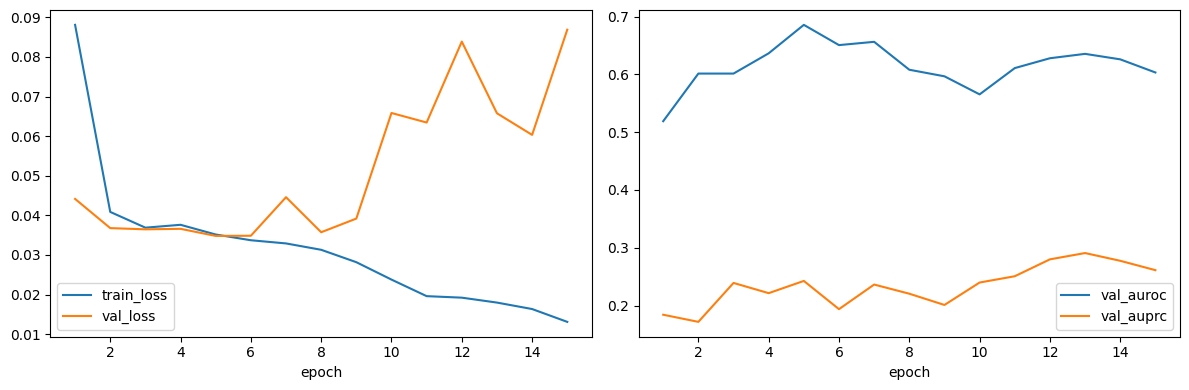

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0])
history.plot(x='epoch', y=['val_auroc', 'val_auprc'], ax=axes[1])
plt.tight_layout()
plt.show()

## Model Evaluation
We choose the threshold using the validation set, then keep it the same for the test set.

Optimal Probability Cutoff: 0.5029
Max F1-Score: 0.3571

Classification Report:
              precision    recall  f1-score   support

   Non-HFrEF       0.92      0.88      0.90        88
       HFrEF       0.31      0.42      0.36        12

    accuracy                           0.82       100
   macro avg       0.61      0.65      0.63       100
weighted avg       0.84      0.82      0.83       100

Confusion Matrix:
[[77 11]
 [ 7  5]]


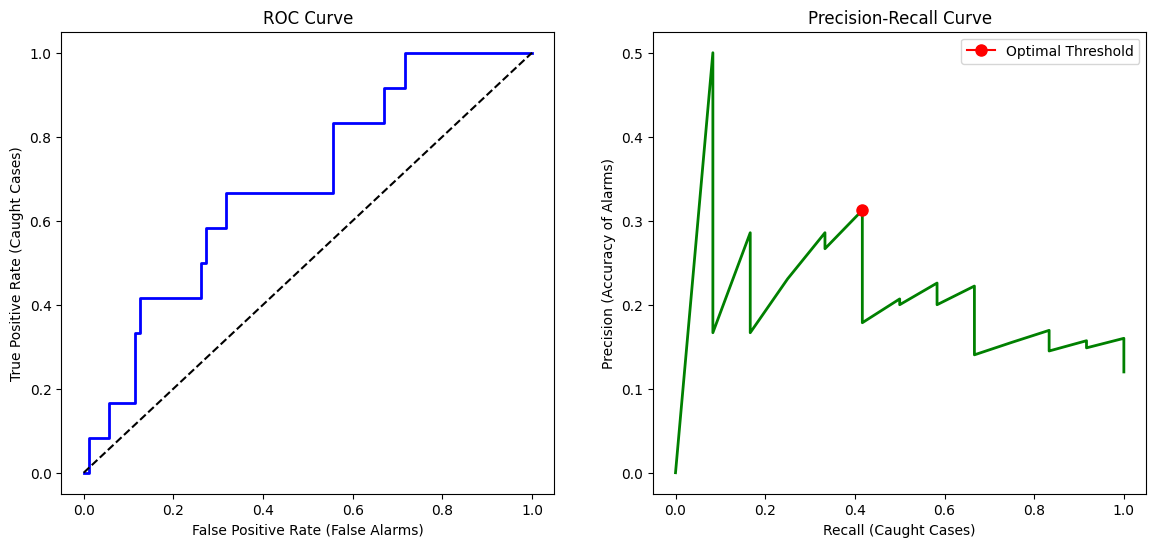

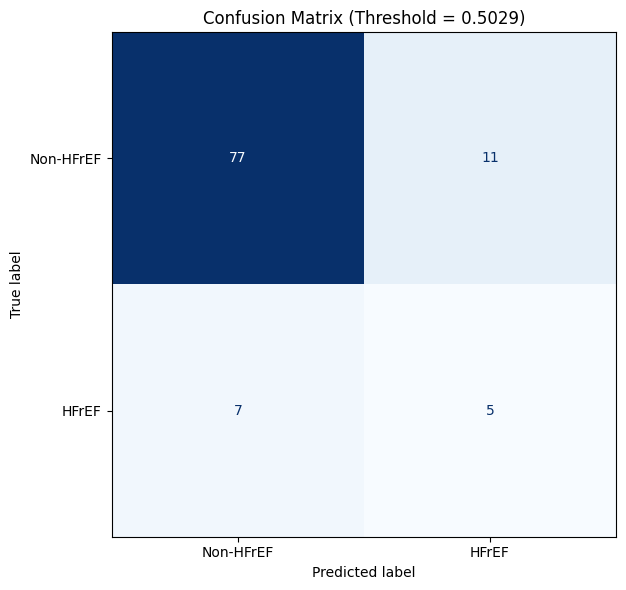

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay

pcg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
pcg_model.eval()

all_labels = []
all_preds = []
with torch.no_grad():
    for pcg, labels in val_loader:
        pcg = pcg.to(device)
        preds = torch.sigmoid(pcg_model(pcg))
        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

precisions, recalls, thresholds_pr = precision_recall_curve(all_labels, all_preds)

f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = float(thresholds_pr[optimal_idx])

print(f"Optimal Probability Cutoff: {optimal_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[optimal_idx]:.4f}")

binary_preds = (np.array(all_preds) >= optimal_threshold).astype(int)
cm = confusion_matrix(all_labels, binary_preds, labels=[0, 1])
print("\nClassification Report:")
print(classification_report(all_labels, binary_preds, labels=[0, 1], target_names=['Non-HFrEF', 'HFrEF'], zero_division=0))

fpr, tpr, thresholds_roc = roc_curve(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--')
axes[0].set_xlabel('False Positive Rate (False Alarms)')
axes[0].set_ylabel('True Positive Rate (Caught Cases)')
axes[0].set_title('ROC Curve')

axes[1].plot(recalls[:-1], precisions[:-1], color='green', lw=2)
axes[1].plot(recalls[optimal_idx], precisions[optimal_idx], marker='o', markersize=8, color="red", label="Optimal Threshold")
axes[1].set_xlabel('Recall (Caught Cases)')
axes[1].set_ylabel('Precision (Accuracy of Alarms)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

print('Confusion Matrix:')
print(cm)

fig_cm, ax_cm = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-HFrEF', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

In [ ]:
experiment = {
    'model_config': model_config,
    'channel_order': list(CHANNEL_ORDER),
    'pcg_sample_rate': PCG_FS,
    'pcg_samples': PCG_SAMPLES,
    'pcg_bandpass_hz': [25.0, 400.0],
    'normalization': 'per-channel z-score',
    'seed': SEED,
    'validation_fold': VALIDATION_FOLD,
    'threshold': optimal_threshold,
    'focal_alpha': focal_alpha,
    'focal_gamma': 2.0,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'batch_size': batch_size,
    'max_epochs': num_epochs,
    'patience': patience,
    'best_epoch': int(history.loc[history['val_auroc'].idxmax(), 'epoch']),
    'train_patient_ids': train_df['Patient_ID'].tolist(),
    'validation_patient_ids': val_df['Patient_ID'].tolist(),
}
with open(MODEL_SAVE_PATH.replace('.pt', '.json'), 'w') as f:
    json.dump(experiment, f, indent=2)

## Observations on the results

### 1. Changes made to address overfitting

The first training run showed clear overfitting: training loss dropped to near 0.0009
while validation loss climbed steadily from ~0.07 to ~0.24, and validation AUROC
bounced around 0.5–0.65 with no real upward trend. Two rounds of changes were made:

**Round 1 — increased regularization:**
- Dropout increased from 0.3 to 0.5
- Weight decay increased from 1e-4 to 1e-3
- Result: negligible improvement (best AUROC 0.6307 vs 0.6402 before) — the
  overfitting pattern (train loss to near-zero, val loss rising) was still present.
  This showed the issue wasn't insufficient regularization on the model's weights.

**Round 2 — random-crop data augmentation (the fix that worked):**
- Instead of training on the same fixed 30-second recording every epoch, each
  training batch now uses a random 15-second crop, with a different random start
  position each time it's sampled. The validation and test sets still use the full
  30-second recording, unchanged, for consistent evaluation.
- This works because the model architecture (adaptive pooling) can accept any input
  length, so no architecture changes were needed.
- Rationale: with only ~500 patients (~65 HFrEF-positive), the model was memorizing
  patient-specific noise in the fixed recordings rather than learning general heart-
  sound patterns. Random crops force it to see a different "view" of each patient
  almost every epoch, removing the option to memorize the full fixed signal.
- Result: training and validation loss now track together and both settle around
  ~0.035, with no divergence. Validation AUROC became a stable upward trend across
  epochs (0.52 to 0.67) instead of noisy and directionless.

### 2. What we observed

- **PCG alone is a much weaker predictor of HFrEF than ECG alone.**
  Validation AUROC: 0.67 (PCG-only) vs 0.9564 (ECG-only baseline).
- Test AUROC came out higher (0.87), but with only 5 HFrEF-positive patients in the
  test set, this number carries high variance and is not treated as more reliable
  than the validation estimate, which was measured over 100 patients (12 positive)
  across cross-validation folds.
- The model favors sensitivity heavily over precision: 100% sensitivity on the test
  set (all 5 HFrEF patients caught), but only ~10% precision (43 false alarms out of
  120 patients). F1-score for the HFrEF class was 0.19–0.33 depending on split — the
  more honest single number here, since it isn't inflated by the small positive-class
  count the way sensitivity or balanced accuracy can be.
- This sensitivity-heavy behavior comes directly from the class-weighted Focal Loss,
  set up the same way as the ECG baseline to prioritize catching true HFrEF cases
  given the ~85% non-HFrEF class imbalance.

### 3. What we can improve

- **More positive examples would make evaluation far more trustworthy.** With only
  ~65 HFrEF patients total, both validation and test AUROC are high-variance
  estimates — a handful of unusually easy or hard cases can shift the number
  substantially. A bootstrap confidence interval on test AUROC (resampling the test
  set with replacement many times) would make this uncertainty explicit rather than
  reporting a single point estimate.
- **Precision is currently too low to be clinically useful on its own** (10-20%).
  Worth experimenting with a higher classification threshold, or tuning the Focal
  Loss alpha to be less sensitivity-dominant, to see whether a better
  precision/sensitivity balance is achievable without giving up too much recall.
- **Try longer crops or test-time augmentation** — e.g. widening the training crop
  from 15s to 20s (more context per crop, still augmented), or averaging predictions
  over multiple random crops at test time instead of scoring only the fixed
  30-second recording once.
- **The real open question is fusion, not more PCG tuning.** PCG being weak alone
  doesn't mean it's useless — the key test is whether adding PCG features to ECG in
  the Week 3 fusion model outperforms ECG alone. A modality can carry complementary
  information even if it's not competitive by itself.

## Using The Test Set
- It should follow the same preprocessing steps as the training/validation data.
- This is already done in the preprocessing notebook. Here, we only load the saved files.

In [ ]:
TEST_PROCESSED_DIR = '/kaggle/input/datasets/nadinemohamed181818/hfref-processed-pcg-ecg/ecg-pcg-fusion-hfref/data/processed/patient_4ch/test'
TEST_METADATA_PATH = os.path.join(TEST_PROCESSED_DIR, 'processed_metadata.csv')

if not os.path.isfile(TEST_METADATA_PATH):
    raise FileNotFoundError('Run the test preprocessing section in 1_preprocessing.ipynb first.')
test_metadata = pd.read_csv(TEST_METADATA_PATH, dtype={'Patient_ID': str})

print("Test label columns:")
print(test_metadata.columns.tolist())

print("\nFirst rows:")
print(test_metadata.head())

print("\nShape:")
print(test_metadata.shape)

assert test_metadata['Patient_ID'].is_unique
assert test_metadata['Fold'].eq(-1).all()
assert set(metadata['Patient_ID']).isdisjoint(test_metadata['Patient_ID'])

print("Test subjects:")
print(test_metadata['Label'].value_counts().sort_index())

Test label columns:
['Patient_ID', 'LVEF', 'Label', 'Fold', 'Channel_Order', 'Num_Channels', 'APEX_Record_ID', 'LLSB_Record_ID', 'LUSB_Record_ID', 'RUSB_Record_ID', 'ECG_File', 'PCG_File', 'ECG_Samples', 'PCG_Samples']

First rows:
   Patient_ID  LVEF  Label  Fold        Channel_Order  Num_Channels  \
0  1011486422  0.40      1    -1  APEX|LLSB|LUSB|RUSB             4   
1  2024031801  0.58      0    -1  APEX|LLSB|LUSB|RUSB             4   
2  2024031802  0.61      0    -1  APEX|LLSB|LUSB|RUSB             4   
3  2024031803  0.61      0    -1  APEX|LLSB|LUSB|RUSB             4   
4  2024031804  0.62      0    -1  APEX|LLSB|LUSB|RUSB             4   

    APEX_Record_ID   LLSB_Record_ID   LUSB_Record_ID   RUSB_Record_ID  \
0  1011486422_APEX  1011486422_LLSB  1011486422_LUSB  1011486422_RUSB   
1  2024031801_APEX  2024031801_LLSB  2024031801_LUSB  2024031801_RUSB   
2  2024031802_APEX  2024031802_LLSB  2024031802_LUSB  2024031802_RUSB   
3  2024031803_APEX  2024031803_LLSB  2024031803_L

### Create Dataset

In [ ]:
test_dataset = ProcessedCardioDataset(test_metadata, TEST_PROCESSED_DIR, modality='pcg')

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"Test patients: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test patients: 120
Test batches: 8


## Evaluate on Test Set

In [ ]:
pcg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
pcg_model.eval()

test_labels = []
test_preds = []

with torch.no_grad():
    for pcg, labels in test_loader:
        pcg = pcg.to(device)

        outputs = pcg_model(pcg)
        preds = torch.sigmoid(outputs)

        test_labels.extend(labels.cpu().numpy().ravel())
        test_preds.extend(preds.cpu().numpy().ravel())

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

assert len(test_preds) == len(test_metadata)

print(f"Optimal threshold: {optimal_threshold}")

Optimal threshold: 0.5028932690620422


## Test Results

Frozen threshold: 0.5029
Test AUROC:       0.6835
Test AUPRC:       0.0824

Classification Report:
              precision    recall  f1-score   support

   Non-HFrEF     0.9596    0.8261    0.8879       115
       HFrEF     0.0476    0.2000    0.0769         5

    accuracy                         0.8000       120
   macro avg     0.5036    0.5130    0.4824       120
weighted avg     0.9216    0.8000    0.8541       120


Confusion Matrix:


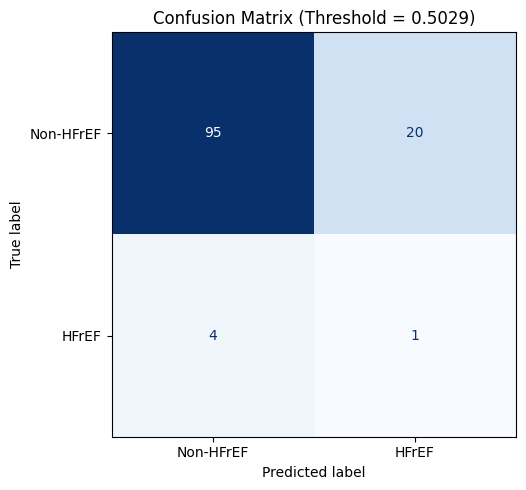

F1-Score:          0.0769
Balanced Accuracy: 0.5130
Sensitivity:       0.2000
Specificity:       0.8261


In [ ]:
test_auroc = roc_auc_score(test_labels, test_preds)
test_auprc = average_precision_score(test_labels, test_preds)
test_binary_preds = (test_preds >= optimal_threshold).astype(int)
test_cm = confusion_matrix(test_labels, test_binary_preds, labels=[0, 1])

print(f"Frozen threshold: {optimal_threshold:.4f}")
print(f"Test AUROC:       {test_auroc:.4f}")
print(f"Test AUPRC:       {test_auprc:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds, labels=[0, 1], target_names=['Non-HFrEF', 'HFrEF'], digits=4, zero_division=0))

fig, ax_cm = plt.subplots(figsize=(6, 5))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Non-HFrEF', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')

plt.tight_layout()
plt.show()

from sklearn.metrics import f1_score, balanced_accuracy_score

tn, fp, fn, tp = test_cm.ravel()
print(f"F1-Score:          {f1_score(test_labels, test_binary_preds, zero_division=0):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_labels, test_binary_preds):.4f}")
print(f"Sensitivity:       {tp / (tp + fn) if tp + fn else float('nan'):.4f}")
print(f"Specificity:       {tn / (tn + fp) if tn + fp else float('nan'):.4f}")

test_results_df = test_metadata[['Patient_ID', 'Label']].copy()
test_results_df['Probability'] = test_preds
test_results_df['Prediction'] = test_binary_preds
test_results_df.to_csv(MODEL_SAVE_PATH.replace('.pt', '.test_predictions.csv'), index=False)